<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject1%20/%20Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **import excel files to google colab**

In [ ]:
import pandas as pd
file_path = "/content/mp1_lr_dataset_ai4032.xlsx"
df = pd.read_excel(file_path)
df.head()

,1,2,3,4,5,6,7,8,9,10,...,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000
0,13,29,44,55,61,72,200,96,112,120,...,21680,21692,21697,21705,21711,21729,21742,21746,21763,21777
1,-3980,-3883,-3832,0,-3839,-3788,-3695,-3663,-3669,0,...,7130,7150,7117,7023,7064,0,7027,6929,6954,6867
2,-3959,-4058,-4131,-4033,-4009,-3941,-3996,-4071,-3971,-4021,...,-254,-296,-303,0,-327,-274,-358,-278,-346,-299


# **بخش 2.4.2**

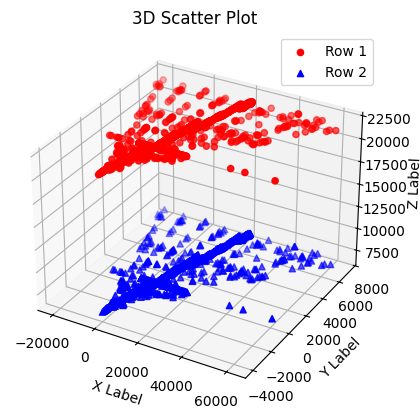

In [ ]:
# Importing necessary libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Loading the dataset from Excel file - update the path to your actual file location
file_path = 'mp1_lr_dataset_ai4032.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Basic data validation - ensuring we have enough rows and columns to work with
if df.shape[0] < 2 or df.shape[1] < 3:
    raise ValueError("The input file must contain at least 2 rows and 3 columns.")

# Extracting the first two rows for our visualization
data_row_1 = df.iloc[0]  # Grab all data from the first row
data_row_2 = df.iloc[1]  # Grab all data from the second row

# Preparing the features (x,y) and target (z) values for plotting
# We're taking all columns except the last one as features
x = data_row_1[:-1].values  # Features from first row (all except last element)
y = data_row_2[:-1].values  # Features from second row (all except last element)

# The target values are the last elements in each row
z1 = data_row_1.iloc[-1]  # Target value from first row
z2 = data_row_2.iloc[-1]  # Target value from second row

# Creating the 3D visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting first row's features with its target value (z1 repeated for each point)
ax.scatter(x, y, [z1] * len(x), c='r', marker='o', label='Row 1')

# Plotting second row's features with its target value (z2 repeated for each point)
ax.scatter(x, y, [z2] * len(x), c='b', marker='^', label='Row 2')

# Adding labels and title to make the plot readable
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.title('3D Scatter Plot')

# Showing the legend and displaying the plot
plt.legend()
plt.show()

# **انواع مدل در پاکسازی دیتاها و در ارجیتال**

Original model: Intercept = 2893.4829627543877, Coefficients = [0.00010648 0.00011876 0.00012695 ... 0.00094357 0.00093318 0.00093983]
Cleaned model: Intercept = 2893.4829627543877, Coefficients = [0.00010648 0.00011876 0.00012695 ... 0.00094357 0.00093318 0.00093983]
MSE - Original: 2.0210779633378977e-22, Cleaned: 2.0210779633378977e-22
MAE - Original: 1.3036090725411972e-11, Cleaned: 1.3036090725411972e-11


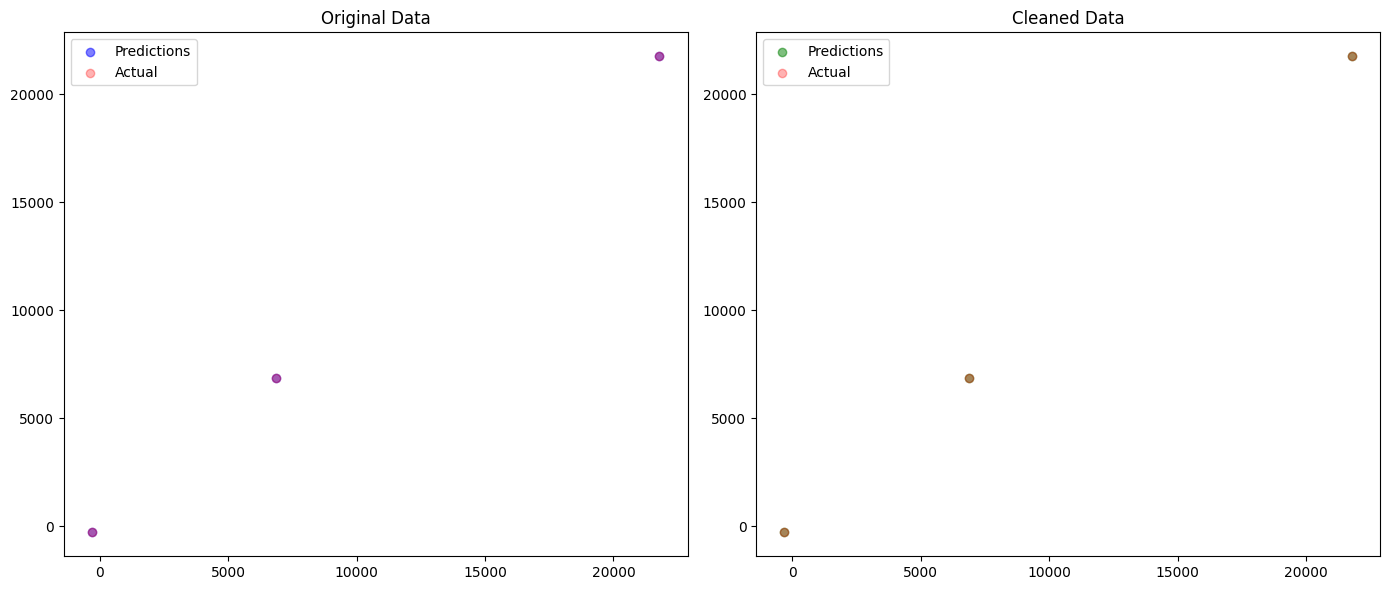

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the dataset - update path to your Excel file
file_path = 'mp1_lr_dataset_ai4032.xlsx'
df = pd.read_excel(file_path)

# Split into features (X) and target (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Quick outlier removal using IQR method
def remove_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_cleaned = remove_outliers(df)
X_cleaned = df_cleaned.iloc[:, :-1].values
y_cleaned = df_cleaned.iloc[:, -1].values

# Train models on both datasets
model_original = LinearRegression()
model_original.fit(X, y)
model_cleaned = LinearRegression()
model_cleaned.fit(X_cleaned, y_cleaned)

# Compare model parameters
print(f'Original model: Intercept = {model_original.intercept_}, Coefficients = {model_original.coef_}')
print(f'Cleaned model: Intercept = {model_cleaned.intercept_}, Coefficients = {model_cleaned.coef_}')

# Calculate performance metrics
print(f'MSE - Original: {mean_squared_error(y, model_original.predict(X))}, Cleaned: {mean_squared_error(y_cleaned, model_cleaned.predict(X_cleaned))}')
print(f'MAE - Original: {mean_absolute_error(y, model_original.predict(X))}, Cleaned: {mean_absolute_error(y_cleaned, model_cleaned.predict(X_cleaned))}')

# Visual comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y, model_original.predict(X), color='blue', alpha=0.5, label='Predictions')
plt.scatter(y, y, color='red', alpha=0.3, label='Actual')
plt.title('Original Data')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_cleaned, model_cleaned.predict(X_cleaned), color='green', alpha=0.5, label='Predictions')
plt.scatter(y_cleaned, y_cleaned, color='red', alpha=0.3, label='Actual')
plt.title('Cleaned Data')
plt.legend()

plt.tight_layout()
plt.show()

# **اموزش رگرسیوم مقاوم**

RANSAC: Intercept = 2893.4829627543877, Coefficients = [0.00010648 0.00011876 0.00012695 ... 0.00094357 0.00093318 0.00093983]
Theil-Sen: Intercept = 3.0176821625124873e-07, Coefficients = [-0.00111434 -0.00110276 -0.00109824 ...  0.00183212  0.00181922
  0.00181902]
MSE - RANSAC: 2.0210779633378977e-22, Theil-Sen: 1.136953289605601e-22
MAE - RANSAC: 1.3036090725411972e-11, Theil-Sen: 1.0516032489249483e-11


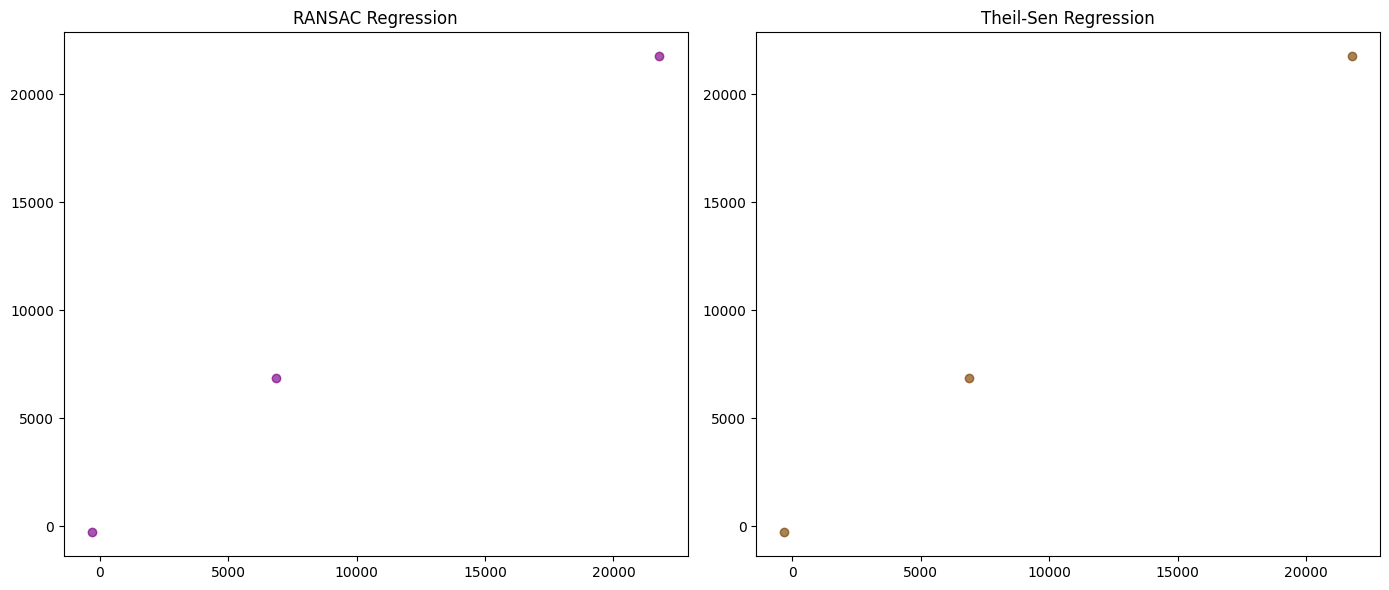

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, TheilSenRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset - update path to your Excel file
file_path = 'mp1_lr_dataset_ai4032.xlsx'
df = pd.read_excel(file_path)

# Split data into features (X) and target (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Initialize robust regression models
model_ransac = RANSACRegressor(min_samples=2)  # Using minimal samples for small datasets
model_theil_sen = TheilSenRegressor()  # Default Theil-Sen estimator

# Fit models
model_ransac.fit(X, y)
model_theil_sen.fit(X, y)

# Compare model coefficients
print(f'RANSAC: Intercept = {model_ransac.estimator_.intercept_}, Coefficients = {model_ransac.estimator_.coef_}')
print(f'Theil-Sen: Intercept = {model_theil_sen.intercept_}, Coefficients = {model_theil_sen.coef_}')

# Print error metrics
print(f'MSE - RANSAC: {mean_squared_error(y, model_ransac.predict(X))}, Theil-Sen: {mean_squared_error(y, model_theil_sen.predict(X))}')
print(f'MAE - RANSAC: {mean_absolute_error(y, model_ransac.predict(X))}, Theil-Sen: {mean_absolute_error(y, model_theil_sen.predict(X))}')

# Visual comparison
plt.figure(figsize=(14, 6))

# RANSAC results
plt.subplot(1, 2, 1)
plt.scatter(y, model_ransac.predict(X), color='blue', alpha=0.5, label='Predictions')
plt.scatter(y, y, color='red', alpha=0.3, label='Actual')
plt.title('RANSAC Regression')

# Theil-Sen results
plt.subplot(1, 2, 2)
plt.scatter(y, model_theil_sen.predict(X), color='green', alpha=0.5, label='Predictions')
plt.scatter(y, y, color='red', alpha=0.3, label='Actual')
plt.title('Theil-Sen Regression')

plt.tight_layout()
plt.show()

# **import pandas as pd**

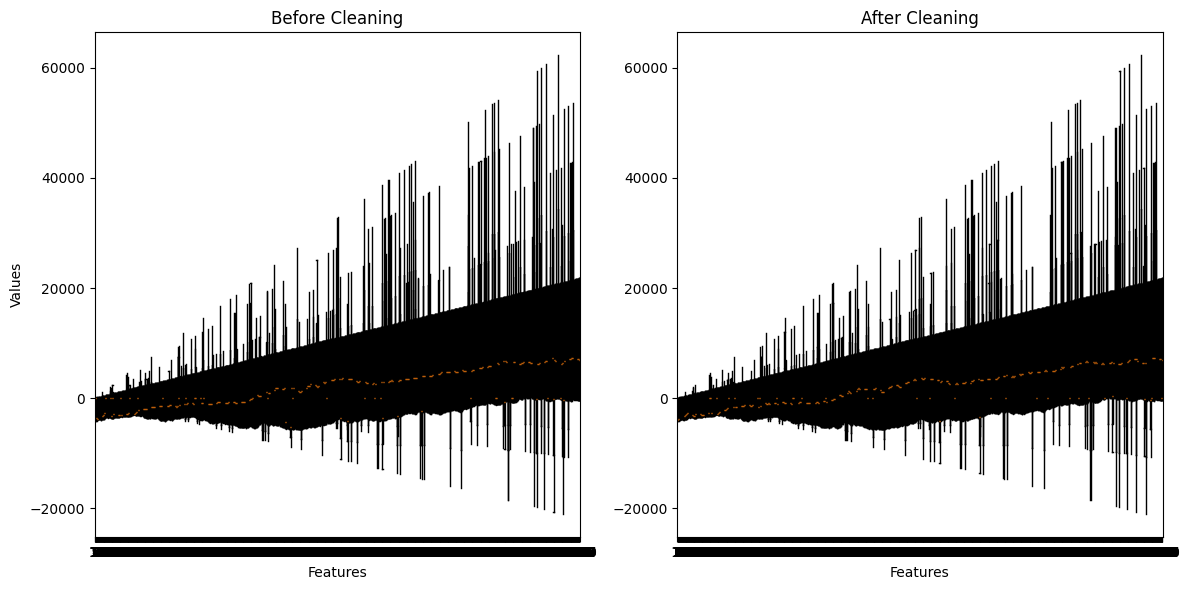

In [ ]:
# Identifying and handling outliers in our dataset
import pandas as pd
import numpy as np

# Loading our Excel data file
file_path = 'mp1_lr_dataset_ai4032.xlsx'
df = pd.read_excel(file_path)

# Calculating quartiles for outlier detection
Q1 = df.quantile(0.25)  # 25th percentile
Q3 = df.quantile(0.75)  # 75th percentile
IQR = Q3 - Q1  # Interquartile range

# Filtering out outliers (1.5*IQR rule)
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Alternative approach: replace outliers with neighboring values' average
for col in df.columns:
    # Find outlier positions in this column
    outliers = df[(df[col] < (Q1[col] - 1.5 * IQR[col])) | (df[col] > (Q3[col] + 1.5 * IQR[col]))]

    # For each outlier, use nearby values to calculate replacement
    for index in outliers.index:
        neighbors = df.iloc[max(0, index - 1):min(len(df), index + 2)]
        df.at[index, col] = neighbors[col].mean()

# Keeping our final cleaned dataset
df_final = df.copy()

# Visual comparison of original vs cleaned data
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Original data boxplot
plt.subplot(1, 2, 1)
plt.title('Before Cleaning')
plt.boxplot(df.values)
plt.xlabel('Features')
plt.ylabel('Values')

# Cleaned data boxplot
plt.subplot(1, 2, 2)
plt.title('After Cleaning')
plt.boxplot(df_final.values)
plt.xlabel('Features')

plt.tight_layout()
plt.show()